<a href="https://colab.research.google.com/github/youssefsalah224/NBA_Players_Shooting_Data_science/blob/main/NBA_Players_Shooting_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("/content/nba_players_shooting.csv")
df.head()

,INDEX,SHOOTER,X,Y,RANGE,DEFENDER,SCORE
0,0,Seth Curry,-3.808987,0.583621,"(0, 4)",Chris Paul,MADE
1,1,Seth Curry,-0.104279,0.919138,"(0, 4)",Trae Young,MADE
2,2,Seth Curry,-0.525864,3.912239,"(0, 4)",Trae Young,MADE
3,3,Seth Curry,-0.790616,2.503782,"(0, 4)",Chris Paul,MADE
4,4,Seth Curry,2.119074,0.320534,"(0, 4)",Trae Young,MADE


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 776 entries, 0 to 775
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   INDEX     776 non-null    int64  
 1   SHOOTER   776 non-null    object 
 2   X         776 non-null    float64
 3   Y         776 non-null    float64
 4   RANGE     776 non-null    object 
 5   DEFENDER  776 non-null    object 
 6   SCORE     776 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 42.6+ KB


In [18]:
df.describe()

,INDEX,X,Y
count,776.000000,776.000000,776.000000
mean,387.500000,0.506853,10.400099
std,224.156196,13.331958,8.009152
min,0.000000,-28.603445,0.008911
25%,193.750000,-8.227266,3.151474
50%,387.500000,0.318647,8.665261
75%,581.250000,9.782513,16.175087
max,775.000000,28.467268,28.853913


# we know:

*   SHOOTER and DEFENDER are categorical variables taking 4 values (the four player names)
*   RANGE is also categorical containing 6 bins
* SCORE is binary
* X and Y are numerical continuous variables


In [19]:
df.isnull().sum()

,0
INDEX,0
SHOOTER,0
X,0
Y,0
RANGE,0
DEFENDER,0
SCORE,0


In [20]:
df['exacxt_range']=np.sqrt(df.X**2+df.Y**2)

In [21]:
df.head(10)

,INDEX,SHOOTER,X,Y,RANGE,DEFENDER,SCORE,exacxt_range
0,0,Seth Curry,-3.808987,0.583621,"(0, 4)",Chris Paul,MADE,3.853440
1,1,Seth Curry,-0.104279,0.919138,"(0, 4)",Trae Young,MADE,0.925034
2,2,Seth Curry,-0.525864,3.912239,"(0, 4)",Trae Young,MADE,3.947423
3,3,Seth Curry,-0.790616,2.503782,"(0, 4)",Chris Paul,MADE,2.625642
4,4,Seth Curry,2.119074,0.320534,"(0, 4)",Trae Young,MADE,2.143179
5,5,Seth Curry,0.753614,2.053554,"(0, 4)",Chris Paul,MADE,2.187468
6,6,Seth Curry,-2.535078,0.626916,"(0, 4)",Russell Westbrook,MADE,2.611445
7,7,Seth Curry,-3.236863,1.619633,"(0, 4)",Chris Paul,MADE,3.619460
8,8,Seth Curry,2.045765,3.142182,"(0, 4)",Chris Paul,MADE,3.749461
9,9,Seth Curry,2.821609,1.426862,"(0, 4)",Chris Paul,MADE,3.161869


In [85]:
df['RANGE'] = df.RANGE.astype("category")
df['RANGE'] = df.RANGE.cat.reorder_categories(['(0, 4)', '(5, 9)', '(10, 14)', '(15, 19)', '(20, 24)', '(25, 29)'], ordered=True)
df.replace(['MADE' , 'MISSED'] , [1,0] , inplace=True)

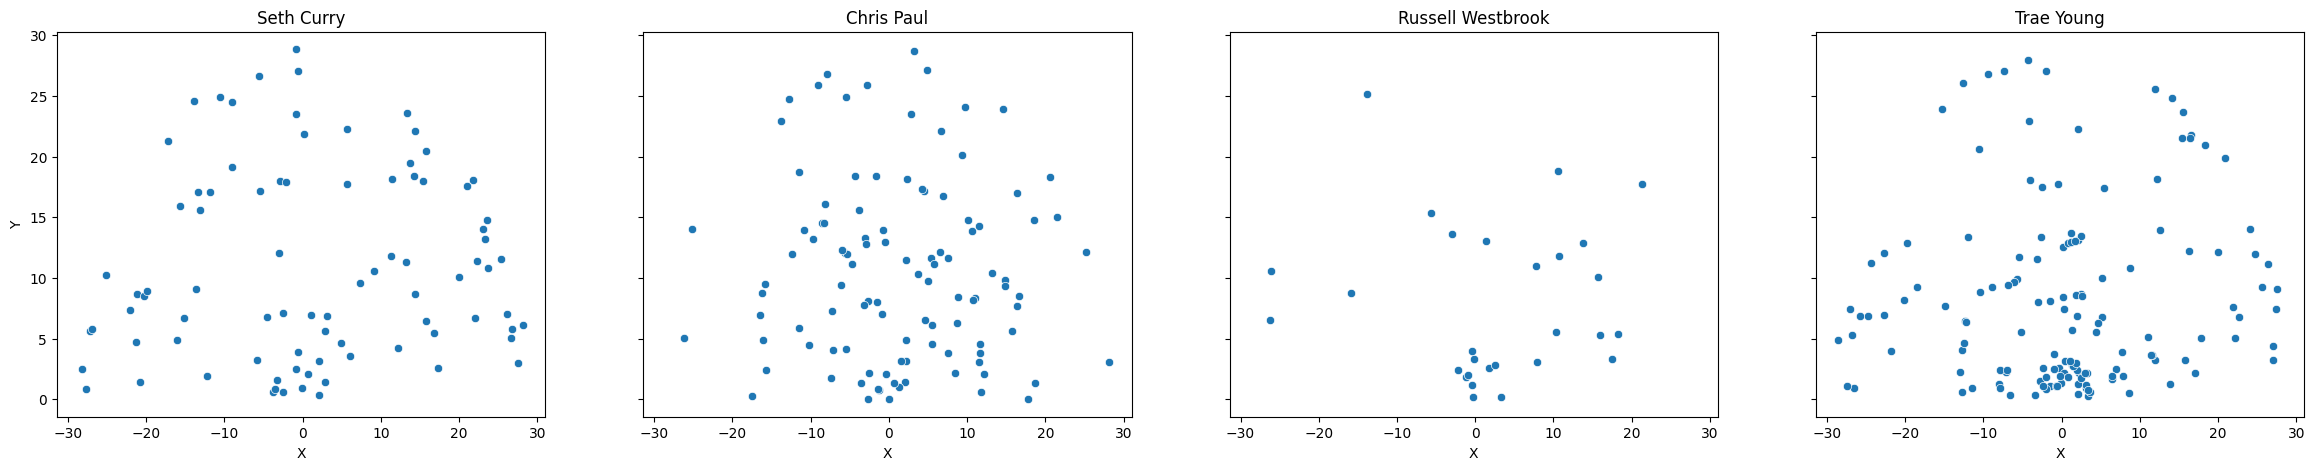

In [86]:
fig,ax = plt.subplots(1,4, figsize=(29,5), sharey=True, sharex=True)
for i,shooter in enumerate(df['SHOOTER'].unique()):
  shooter_made = df.query("SHOOTER == @shooter & SCORE == 1")
  sns.scatterplot(shooter_made , x='X', y='Y',  ax =ax[i])
  ax[i].set_title(shooter)


In [99]:
df.loc[:, "rangeshot"] = np.select(
    [
        df.exacxt_range < 8,
        (df.exacxt_range >= 9) & (df.exacxt_range <= 23),
        df.exacxt_range > 23
    ],
    ["hooping", "midshot", "farshot"],
    default="unknown"
)

df = df[df["rangeshot"] != "unknown"]

df["rangeshot"] = (
    df["rangeshot"]
    .astype("category")
    .cat.remove_unused_categories()
    .cat.reorder_categories(["hooping", "midshot", "farshot"], ordered=True)
)

In [100]:
df.head()

,INDEX,SHOOTER,X,Y,RANGE,DEFENDER,SCORE,exacxt_range,rangeshot
0,0,Seth Curry,-3.808987,0.583621,"(0, 4)",Chris Paul,1,3.853440,hooping
1,1,Seth Curry,-0.104279,0.919138,"(0, 4)",Trae Young,1,0.925034,hooping
2,2,Seth Curry,-0.525864,3.912239,"(0, 4)",Trae Young,1,3.947423,hooping
3,3,Seth Curry,-0.790616,2.503782,"(0, 4)",Chris Paul,1,2.625642,hooping
4,4,Seth Curry,2.119074,0.320534,"(0, 4)",Trae Young,1,2.143179,hooping


/tmp/ipython-input-4114267835.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['SHOOTER','rangeshot'])


Text(170.3222222222223, 0.5, '')

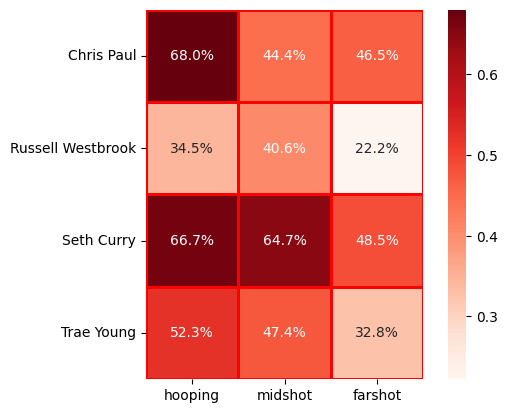

In [101]:
(df
 .groupby(['SHOOTER','rangeshot'])
 .SCORE
 .mean()
 .unstack()
 .pipe(sns.heatmap, cmap='Reds', square=True, annot=True, linecolor='Red', linewidths=1,  fmt='.1%')
)
plt.xlabel(None)
plt.ylabel(None)